In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# Reading in data

In [2]:
#Raw Data

MCSLC_data = pd.read_excel("research_data_export/MCSLC.xlsx")
SPD_Calls_data = pd.read_excel("research_data_export/2015-2025 SPD Calls for Service.xlsx")
SPD_Responding_data = pd.read_excel("research_data_export/2015-2025 SPD Responding Units.xlsx")
SPD_Full = pd.read_excel("research_data_export/SPD_FULL.xlsx")

In [3]:
#CAD data

CAD_2015 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2015noloc.csv")
CAD_2016 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2016noloc.csv")
CAD_2017 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2017noloc.csv")
CAD_2018 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2018noloc.csv")
CAD_2019 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2019noloc.csv")
CAD_2020 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2020noloc.csv")
CAD_2021 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv")
CAD_2022 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2022noloc.csv")
CAD_2023 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2023noloc.csv")
CAD_2024 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2024noloc.csv")
CAD_2025 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv")


CAD_total = pd.concat([CAD_2015,
                       CAD_2016,
                       CAD_2017,
                       CAD_2018,
                       CAD_2019,
                       CAD_2020,
                       CAD_2021,
                       CAD_2022,
                       CAD_2023,
                       CAD_2024,
                       CAD_2025])

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_19935/1264954579.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  CAD_2021 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv")
/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_19935/1264954579.py:13: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  CAD_2025 = pd.read_csv("research_data_export/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv")


# CLEANING/PROCESSING STAGE

In [21]:
#Checking for duplicate values in the CAD dataset
#THIS METHOD PROBABLY NEEDS A SECOND LOOK

duplicates = CAD_total.groupby("inci_id")["primeunit"].count().reset_index()
duplicates[duplicates["primeunit"] > 1]

,inci_id,primeunit


## simplifying dates

In [22]:
#Create a simplified date column for Eugene CAD data.

CAD_total['Date'] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m")

In [23]:
#Creating simplified date column for MCSLC data.

MCSLC_data["Date"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m")

In [24]:
#Creating simplified date column for SPD data.

SPD_Full["Date"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m")

## Subsetting MCSLC data by city

In [25]:
#Subsetting MCSLC data by City

MCSLC_Eugene = MCSLC_data[MCSLC_data["City"] == 'Eugene']
MCSLC_Springfield = MCSLC_data[MCSLC_data["City"] == 'Springfield']

## Subsetting Eugene and Springfield data by agency

In [60]:
#Known CAHOOTS unit codes

#Cahoots_codes1 = CAD_total[CAD_total["nature"] == "CHECK WELFARE, CAHOOTS"]["primeunit"].unique()
Cahoots_codes = np.array(['_CAHOT ', '_TESTCA', '_1J77  ', '_3J78  ', '_4J79  ', '_3J77  ', '_3J79  ',
                          '3J81  ', '3J76  ', '2J28  ', '2J29  ', 'CAHOOT  ', 'CAHOT  ', 'CAHO  '])

In [61]:
#Subsetting Eugene and Springfield call data by known CAHOOTS unit codes

CAHOOTS_EUG = CAD_total[CAD_total["primeunit"].isin(Cahoots_codes)]
EPD = CAD_total[~CAD_total["primeunit"].isin(Cahoots_codes)]

CAHOOTS_SPR = SPD_Full[SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)]
SPD = SPD_Full[~SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)]


## Identifying most common CAHOOTS/MCSLC call types

In [63]:
#Identifying most common CAHOOTS call types in Eugene

Top_Cahoots_natures_EUG = CAHOOTS_EUG.groupby('nature')["yr"].count().sort_values(ascending=False)

Top_Cahoots_natures_EUG[:10]

nature
ASSIST PUBLIC- POLICE        39540
CHECK WELFARE                35105
TRANSPORT                    25035
PUBLIC ASSIST, CAHOOTS       19173
CHECK WELFARE, CAHOOTS       15793
SUICIDAL SUBJECT              6132
TRANSPORT, CAHOOTS            4751
SUICIDAL SUBJECT, CAHOOTS     4344
INTOXICATED SUBJECT           2476
ASSIST PD, CAHOOTS            2175
Name: yr, dtype: int64

In [66]:
#Identifying most common CAHOOTS call types in Springfield

Top_Cahoots_natures_SPR = CAHOOTS_SPR.groupby("Final Call Type")['Incident Number'].count().sort_values(ascending=False)

Top_Cahoots_natures_SPR[:10]

Final Call Type
CHECK WELFARE             18126
ASSIST PUBLIC- POLICE     16656
SUICIDAL SUBJECT           1975
INTOXICATED SUBJECT        1161
DISORDERLY SUBJECT          662
FOUND SYRINGE               619
TRANSPORT                   544
CRIMINAL TRESPASS           405
TRAFFIC HAZARD              357
ASSIST FIRE DEPARTMENT      345
Name: Incident Number, dtype: int64

In [67]:
MCSLC_data.head(3)

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,Reason for Dispatch #3,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Date
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,5.0,NaN,0.0,NaN,2025-05
1,12574,Cancelled,Unknown,2025-12-05 17:41:00,2025-12-05 17:47:00,2025-12-05 18:06:00,NaT,2025-12-05 18:12:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,6.0,19.0,NaN,NaN,2025-12
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,4.0,14.0,2.0,8.0,2025-07


In [68]:
#Identifying most common MCSLC call types

Top_MCSLC_natures = MCSLC_data.groupby("Reason for Dispatch #1")["ID"].count().sort_values(ascending=False)
Top_MCSLC_natures[:10]

Reason for Dispatch #1
Agitation or disruptive behavior             1492
Suicidality or suicide attempt                681
Disorganized behavior                         654
Needing social/mental health services         528
Difficulty functioning                        409
Harm/risk of harm to self/others/property     330
Paranoia                                      116
Substance use                                 115
Adult Social/interpersonal problems           114
Other                                          50
Name: ID, dtype: int64

# IGNORE FOR NOW

In [29]:
#Organizing MCSLC date by call volume

MCSLCdate = MCSLC_data.groupby("Date")["ID"].count().reset_index()
MCSLCdate.head(3)

,Date,ID
0,2024-08,82
1,2024-09,167
2,2024-10,24


In [30]:
#Organizing Eugene CAD call volume by date

CADdate = CAD_total.groupby("Date")["agency"].count().reset_index()
CADdate.head(3)

,Date,agency
0,2015-01,10103
1,2015-02,9619
2,2015-03,10573


In [31]:
#Organizing SPD call volume by date

SPDdate = SPD_Full.groupby("Date")["Responding Agency"].count().reset_index()
SPDdate.head(3)

,Date,Responding Agency
0,2015-01,4766
1,2015-02,4368
2,2015-03,4656


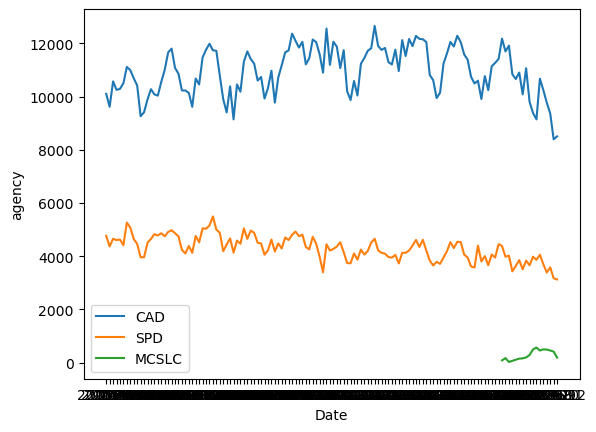

In [32]:
sns.lineplot(data = CADdate, x = "Date", y = "agency", label = "CAD")
sns.lineplot(data = SPDdate, x = "Date", y = "Responding Agency", label = "SPD")
sns.lineplot(data = MCSLCdate, x = "Date", y = "ID", label = "MCSLC")

plt.legend()